# PSMAP visualisation

Visualises the fitted PSMAP surrogate (`PSMAPSurrogate.eval`) used
throughout both pipelines: the differential phase and per-port amplitudes
as a function of initial kinematic coordinates, sliced pairwise. Useful
for sanity-checking a PSMAP file (including a newly-generated one) before
trusting any inference results built on top of it -- e.g. confirm the
phase/amplitude surfaces are smooth (no interpolation artifacts) and have
the expected symmetry/scale.

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from aispy.psmap import load_psmap, PSMAPSurrogate

import sys, os
sys.path.insert(0, os.path.expanduser('~/local/aispy'))

In [2]:
psmap = load_psmap('../output-files/PSGRID4D_CONFOCAL_FINE_Z100.h5')

In [3]:
surrogate = PSMAPSurrogate(psmap, t_det=3.8, use_gpu=True)
print(surrogate._dx)
x = np.linspace(-4e-4, 4e-4, 100)
y = x
X, Y = np.meshgrid(x, y)
V = np.zeros_like(X)

5.9999999999999995e-05


Each cell below evaluates the surrogate on a 2D slice of the 4D phase space (holding the other two coordinates at 0), and plots dphi, amp0, amp1, and the resulting fringe probability as both 3D surfaces and 2D heatmaps.

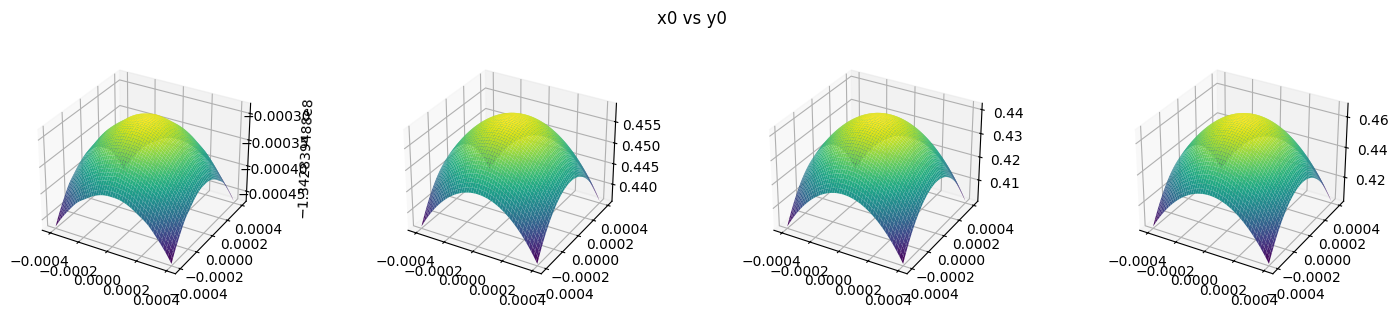

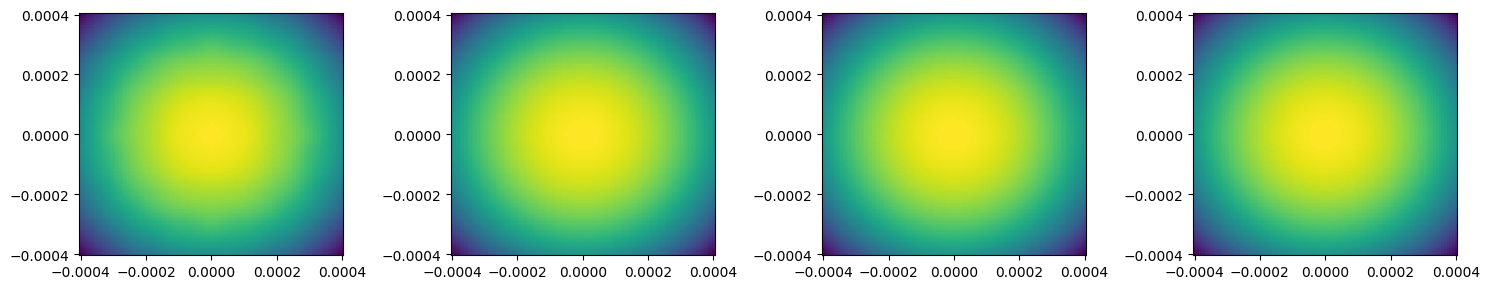

In [4]:
# X0 vs Y0
dphi, a0, a1 = surrogate.eval(X.flatten(), Y.flatten(), V.flatten(), V.flatten())
dphi = dphi[:, 0].reshape(X.shape)
a0 = a0[:, 0].reshape(X.shape)
a1 = a1[:, 0].reshape(X.shape)

fig, ax = plt.subplots(1, 4, figsize=(15, 3), subplot_kw={'projection': '3d'})
ax[0].plot_surface(X, Y, dphi, cmap="viridis")
ax[1].plot_surface(X, Y, a0, cmap="viridis")
ax[2].plot_surface(X, Y, a1, cmap="viridis")
ax[3].plot_surface(X, Y, a0**2 + a1**2 + 2*a0*a1*np.cos(dphi), cmap="viridis")
fig.suptitle('x0 vs y0'); fig.tight_layout()

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].pcolormesh(X, Y, dphi)
ax[1].pcolormesh(X, Y, a0)
ax[2].pcolormesh(X, Y, a1)
ax[3].pcolormesh(X, Y, a0**2 + a1**2 + 2*a0*a1*np.cos(dphi))
fig.tight_layout()
plt.show()

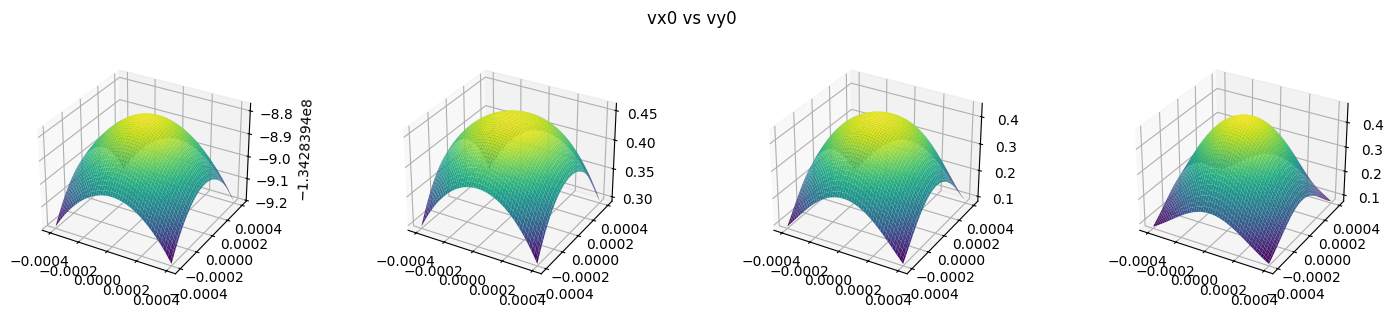

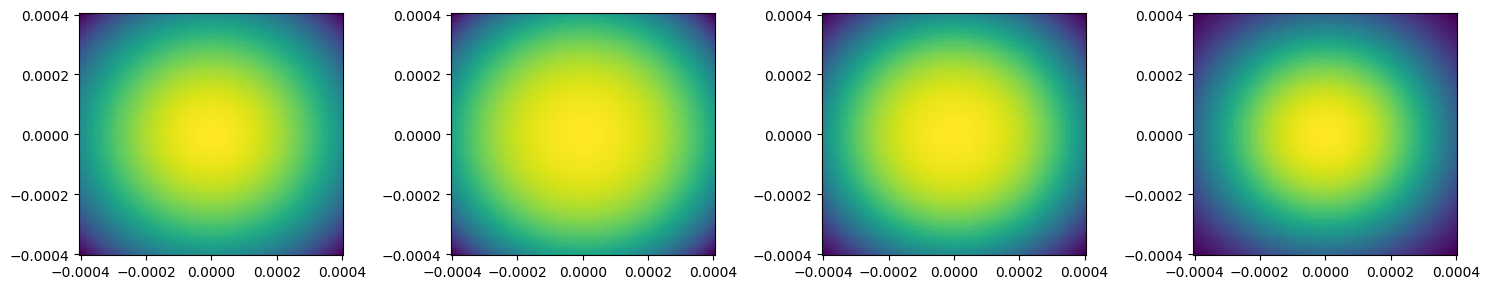

In [5]:
# VX0 vs VY0
dphi, a0, a1 = surrogate.eval(V.flatten(), V.flatten(), X.flatten(), Y.flatten())
dphi = dphi[:, 0].reshape(X.shape)
a0 = a0[:, 0].reshape(X.shape)
a1 = a1[:, 0].reshape(X.shape)

fig, ax = plt.subplots(1, 4, figsize=(15, 3), subplot_kw={'projection': '3d'})
ax[0].plot_surface(X, Y, dphi, cmap="viridis")
ax[1].plot_surface(X, Y, a0, cmap="viridis")
ax[2].plot_surface(X, Y, a1, cmap="viridis")
ax[3].plot_surface(X, Y, a0**2 + a1**2 + 2*a0*a1*np.cos(dphi), cmap="viridis")
fig.suptitle('vx0 vs vy0'); fig.tight_layout()

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].pcolormesh(X, Y, dphi)
ax[1].pcolormesh(X, Y, a0)
ax[2].pcolormesh(X, Y, a1)
ax[3].pcolormesh(X, Y, a0**2 + a1**2 + 2*a0*a1*np.cos(dphi))
fig.tight_layout()
plt.show()

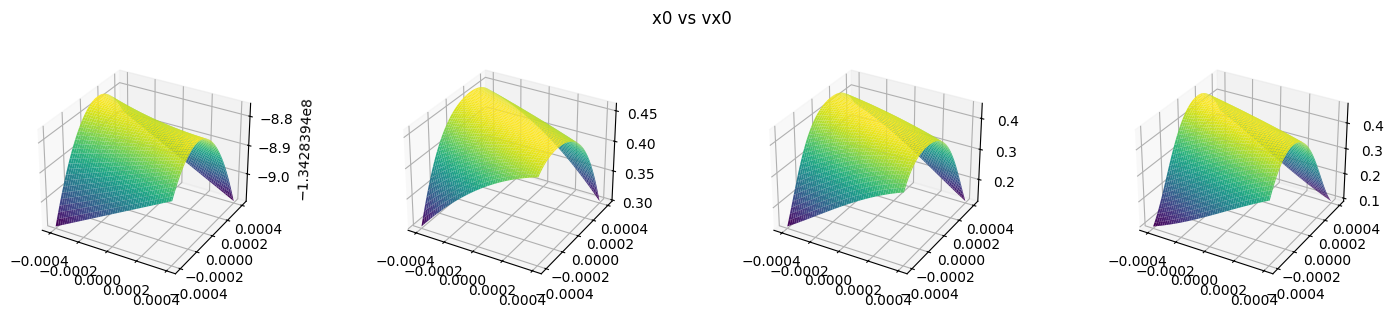

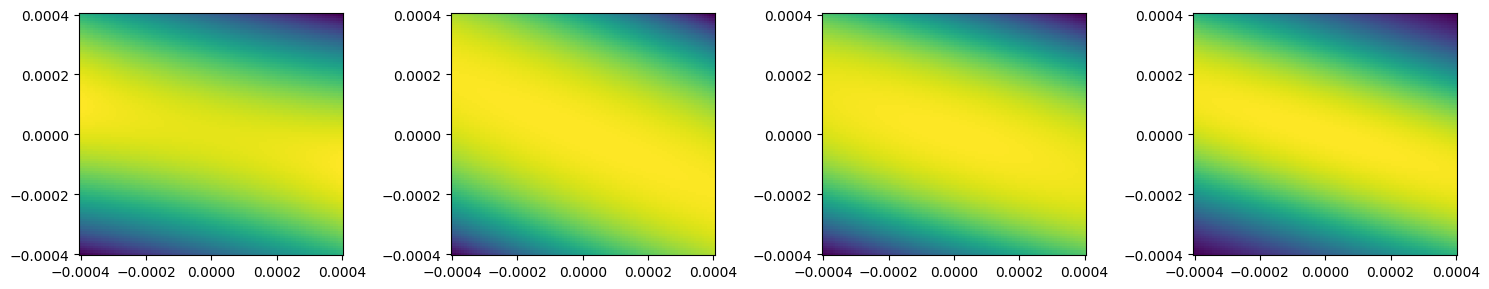

In [6]:
# X0 vs VX0
dphi, a0, a1 = surrogate.eval(X.flatten(), V.flatten(), Y.flatten(), V.flatten())
dphi = dphi[:, 0].reshape(X.shape)
a0 = a0[:, 0].reshape(X.shape)
a1 = a1[:, 0].reshape(X.shape)
prob = a0**2 + a1**2 + 2*a0*a1*np.cos(dphi)

fig, ax = plt.subplots(1, 4, figsize=(15, 3), subplot_kw={'projection': '3d'})
ax[0].plot_surface(X, Y, dphi, cmap="viridis")
ax[1].plot_surface(X, Y, a0, cmap="viridis")
ax[2].plot_surface(X, Y, a1, cmap="viridis")
ax[3].plot_surface(X, Y, prob, cmap="viridis")
fig.suptitle('x0 vs vx0'); fig.tight_layout()

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].pcolormesh(X, Y, dphi)
ax[1].pcolormesh(X, Y, a0)
ax[2].pcolormesh(X, Y, a1)
ax[3].pcolormesh(X, Y, prob)
fig.tight_layout()
plt.show()

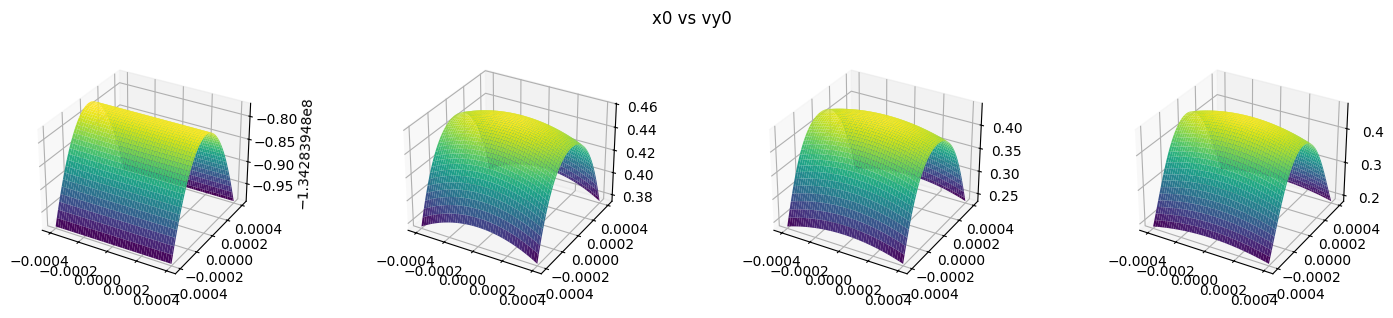

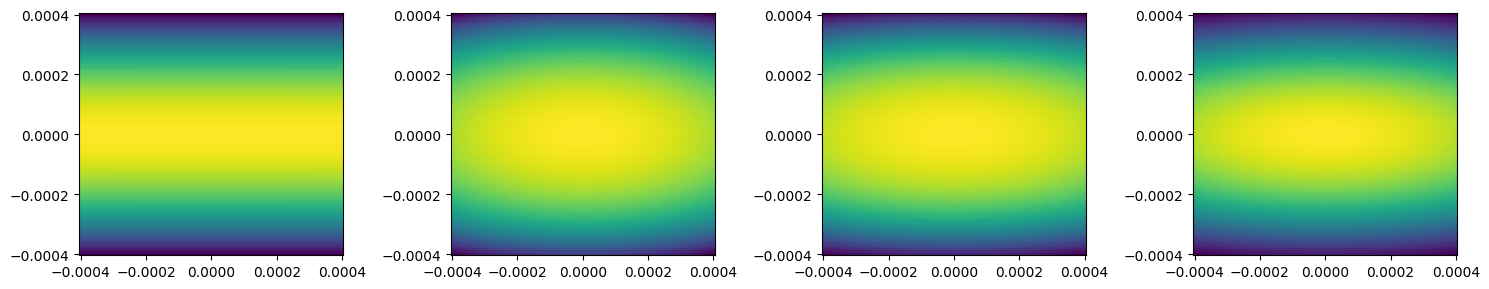

In [7]:
# X0 vs VY0
dphi, a0, a1 = surrogate.eval(X.flatten(), V.flatten(), V.flatten(), Y.flatten())
dphi = dphi[:, 0].reshape(X.shape)
a0 = a0[:, 0].reshape(X.shape)
a1 = a1[:, 0].reshape(X.shape)

fig, ax = plt.subplots(1, 4, figsize=(15, 3), subplot_kw={'projection': '3d'})
ax[0].plot_surface(X, Y, dphi, cmap="viridis")
ax[1].plot_surface(X, Y, a0, cmap="viridis")
ax[2].plot_surface(X, Y, a1, cmap="viridis")
ax[3].plot_surface(X, Y, a0**2 + a1**2 + 2*a0*a1*np.cos(dphi), cmap="viridis")
fig.suptitle('x0 vs vy0'); fig.tight_layout()

fig, ax = plt.subplots(1, 4, figsize=(15, 3))
ax[0].pcolormesh(X, Y, dphi)
ax[1].pcolormesh(X, Y, a0)
ax[2].pcolormesh(X, Y, a1)
ax[3].pcolormesh(X, Y, a0**2 + a1**2 + 2*a0*a1*np.cos(dphi))
fig.tight_layout()
plt.show()